Лабораторна робота №1. Розробка моделей глибокого навчання з використанням Keras.


Завдання 1


1. Використовуючи датасет hourly_wages_data.csv створити модель на базі глибокої нейронної мережі для прогнозування даних.
2. Розбити датасет на 3 підвибірки: тренувальний (70%), валідаційний (20%), тестовий (10%), використовучі власну функцію, або функції які реалізовані в pandas чи sklearn.
3. Дослідити як впливає скейлінг і нормалізація даних на результат моделі https://scikit-learn.org/stable/modules/preprocessing.html
4. Імплементувати модель в Keras за допомогою Sequentinal(). Обґрунтувати обрання кількості нейронів та шарів. Провести
дослідження, як буде мінятися точність мережі при різних гіперпараметрах.
5. В якості оптимізатора застосувати декілька алгоритмів навчання (https://keras.io/api/optimizers/):
    - SGD
    - RMSprop
    - Adam
    - Adadelta
    - Adagrad
    - Adamax
    - Nadam
6. Використати різні активаційні функції і виявити вплив виду функції та точність моделі.
7. Побудувати графіки навчання по кожному оптимізатору і порівняти швидкість збіжності алгоритмів.
8. Провести тестування мережі. Визначити чи не було перенавчання мережі.

All the imports in one place

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('default')

Load the data for the regression

In [2]:
# read in data using pandas
train_df = pd.read_csv('../data/lab1/hourly_wages_data.csv')
# check data has been read in properly
train_df.head()

,wage_per_hour,union,education_yrs,experience_yrs,age,female,marr,south,manufacturing,construction
0,5.10,0,8,21,35,1,1,0,1,0
1,4.95,0,9,42,57,1,1,0,1,0
2,6.67,0,12,1,19,0,0,0,1,0
3,4.00,0,12,4,22,0,0,0,0,0
4,7.50,0,12,17,35,0,1,0,0,0


In [3]:
train_df.describe(include='all')

,wage_per_hour,union,education_yrs,experience_yrs,age,female,marr,south,manufacturing,construction
count,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000,534.000000
mean,9.024064,0.179775,13.018727,17.822097,36.833333,0.458801,0.655431,0.292135,0.185393,0.044944
std,5.139097,0.384360,2.615373,12.379710,11.726573,0.498767,0.475673,0.455170,0.388981,0.207375
min,1.000000,0.000000,2.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.250000,0.000000,12.000000,8.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.780000,0.000000,12.000000,15.000000,35.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,11.250000,0.000000,15.000000,26.000000,44.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,44.500000,1.000000,18.000000,55.000000,64.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
train_df.isna().sum()

wage_per_hour     0
union             0
education_yrs     0
experience_yrs    0
age               0
female            0
marr              0
south             0
manufacturing     0
construction      0
dtype: int64

Split data into training features and feature to predict

In [5]:
y = train_df['wage_per_hour']
train_df = train_df.drop('wage_per_hour', axis=1)
X = train_df

In [6]:
y.head()

0    5.10
1    4.95
2    6.67
3    4.00
4    7.50
Name: wage_per_hour, dtype: float64

In [7]:
X.head()

,union,education_yrs,experience_yrs,age,female,marr,south,manufacturing,construction
0,0,8,21,35,1,1,0,1,0
1,0,9,42,57,1,1,0,1,0
2,0,12,1,19,0,0,0,1,0
3,0,12,4,22,0,0,0,0,0
4,0,12,17,35,0,1,0,0,0


Split the data into training, validation and test datasets

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
  X,y, random_state=42, test_size=0.3, shuffle=True)

In [9]:
X_test, X_val, y_test, y_val = train_test_split(
  X_test,y_test, random_state=42, test_size=0.33, shuffle=True)

Do data scaling for better results

In [10]:
scaler = StandardScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)

X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)


y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()
y_val = y_scaler.transform(y_val.values.reshape(-1, 1)).ravel()

In [11]:
X_train

array([[-0.49328829, -0.40943339, -0.32725953, ..., -0.63423626,
        -0.45080573, -0.21852416],
       [-0.49328829, -0.40943339,  0.41857228, ..., -0.63423626,
        -0.45080573, -0.21852416],
       [ 2.02721214, -0.40943339,  0.66718288, ..., -0.63423626,
         2.21825042, -0.21852416],
       ...,
       [-0.49328829, -0.40943339,  1.66162529, ..., -0.63423626,
        -0.45080573, -0.21852416],
       [-0.49328829,  1.89285787, -0.82448074, ..., -0.63423626,
        -0.45080573, -0.21852416],
       [-0.49328829, -0.40943339, -0.82448074, ..., -0.63423626,
        -0.45080573, -0.21852416]], shape=(373, 9))

Create model

In [12]:
def build_model(train, activator='relu', optimizer='adam', layers=2, neurons=64):
  model = Sequential()
  # get number of columns in training data
  n_cols = train.shape[1]
  # add model layers
  model.add(Input(shape=(n_cols,)))

  model.add(Dense(neurons, activation=activator))
  for i in range(layers-1):
      model.add(Dense(neurons, activation=activator))
  model.add(Dense(1))

  # compile model using mse as a measure of model performance
  model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
  return model

In [13]:
def get_metrics(test_y, y_pred):
  rmse = round(root_mean_squared_error(test_y, y_pred), 3)
  mae = round(mean_absolute_error(test_y, y_pred), 3)
  r2 = round(r2_score(test_y, y_pred), 3)
  return rmse, mae, r2

Try different optimizers in models

In [14]:
optimizers = ['adam', 'rmsprop', 'sgd', 'adadelta', 'adagrad', 'adamax', 'nadam']
activators = ['relu', 'tanh', 'sigmoid', 'softmax', 'silu', 'elu', 'gelu']

models_opt_act = []
metrics_opt_act = []

histories = []
predictions = []

for opt in optimizers:
    models = []
    pred = []
    hists = []
    metr = []
    for act in activators:

        model = build_model(X_train, optimizer=opt, activator=act)
        models.append(model)

        early_stopping_monitor = EarlyStopping(patience=3)
        history = model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=100,
            callbacks=[early_stopping_monitor],
            verbose=0
        )
        hists.append(history.history)

        test_y_predictions = model.predict(X_test)
        pred.append(test_y_predictions)

        test_y_predictions = model.predict(X_test)
        new_metrics = get_metrics(y_test, test_y_predictions)
        metr.append(new_metrics)

    models_opt_act = models
    histories.append(hists)
    predictions.append(pred)
    metrics_opt_act.append(metr)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━

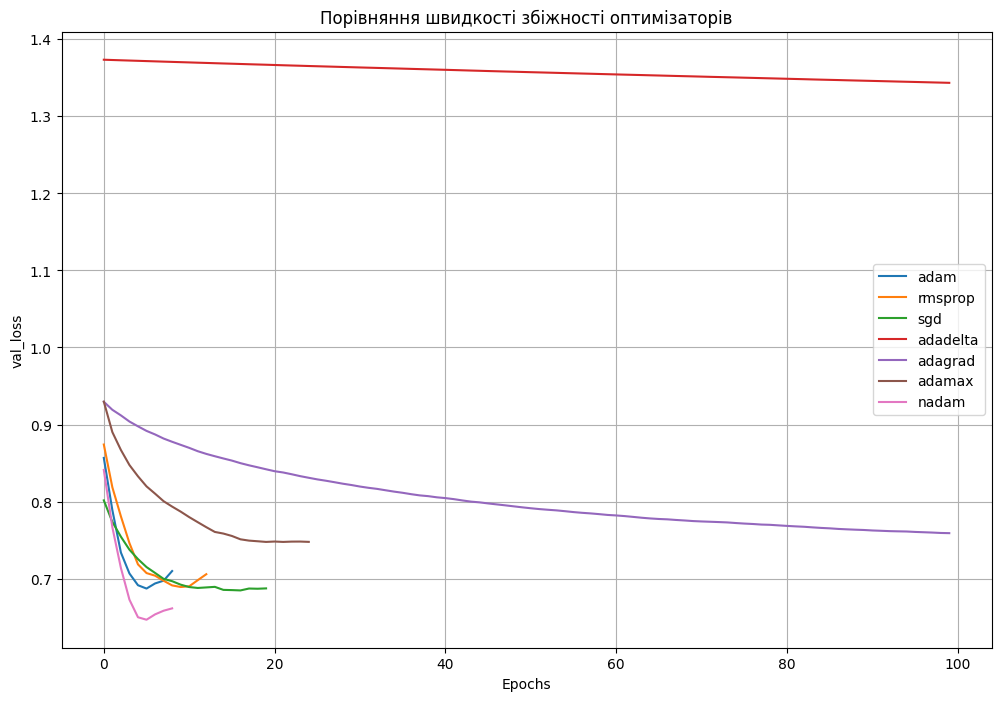

In [15]:
plt.figure(figsize=(12, 8))

# Store validation loss curves and create final loss matrix
val_loss = []
final_loss_matrix = np.zeros((len(optimizers), len(activators)))

for opt_idx, (opt, history) in enumerate(zip(optimizers, histories)):
    plt.plot(history[0]['val_loss'], label=opt)

    for act_idx in range(len(activators)):
        loss_curve = history[act_idx]['val_loss']
        val_loss.append(loss_curve)
        # Store final loss value
        final_loss_matrix[opt_idx, act_idx] = loss_curve[-1]

plt.title('Порівняння швидкості збіжності оптимізаторів')
plt.xlabel('Epochs')
plt.ylabel('val_loss')
plt.legend()
plt.grid(True)
plt.show()

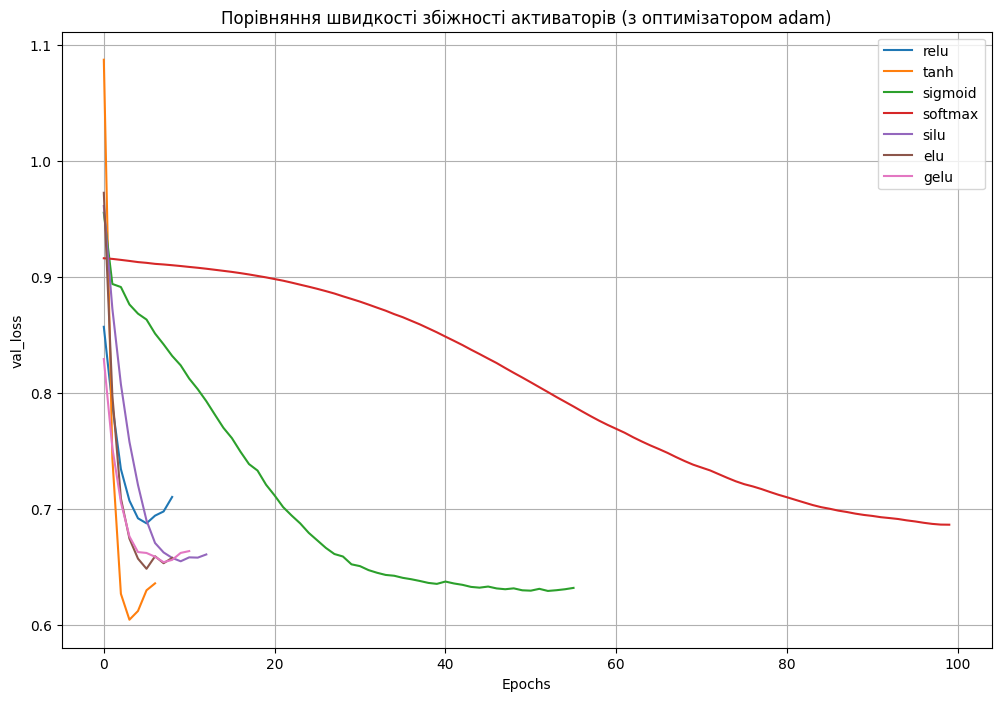

In [16]:
plt.figure(figsize=(12, 8))

# Store validation loss curves and create final loss matrix
val_loss = []
final_loss_matrix = np.zeros((len(activators), len(optimizers)))

for act_idx, act in enumerate(activators):
    # Для кожного активатора беремо першу модель (з оптимізатором 'adam')
    history_for_act = histories[0][act_idx]  # histories[0] - це для 'adam' оптимізатора
    plt.plot(history_for_act['val_loss'], label=act)

    for opt_idx in range(len(optimizers)):
        loss_curve = histories[opt_idx][act_idx]['val_loss']
        val_loss.append(loss_curve)
        # Store final loss value
        final_loss_matrix[act_idx, opt_idx] = loss_curve[-1]

plt.title('Порівняння швидкості збіжності активаторів (з оптимізатором adam)')
plt.xlabel('Epochs')
plt.ylabel('val_loss')
plt.legend()
plt.grid(True)
plt.show()

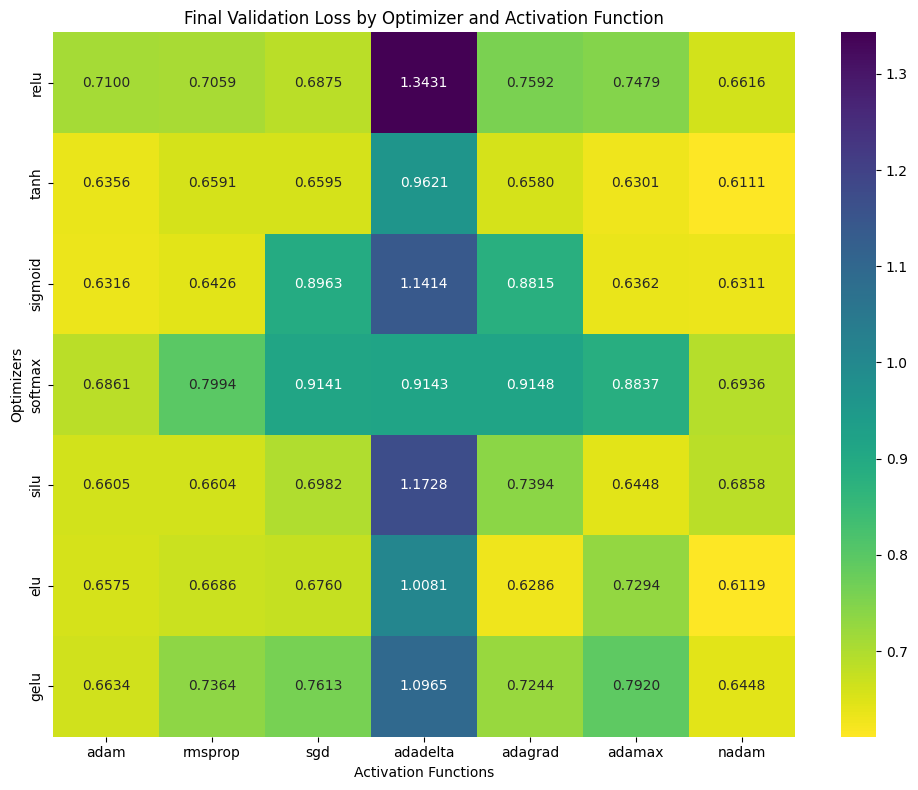

In [17]:
# Plot heatmap of final loss values
plt.figure(figsize=(10, 8))
sns.heatmap(final_loss_matrix,
            xticklabels=optimizers,
            yticklabels=activators,
            annot=True,
            fmt='.4f',
            cmap='viridis_r')
plt.title('Final Validation Loss by Optimizer and Activation Function')
plt.xlabel('Activation Functions')
plt.ylabel('Optimizers')
plt.tight_layout()
plt.show()

In [18]:
best_act_idx, best_opt_idx = np.unravel_index(np.argmin(final_loss_matrix), final_loss_matrix.shape)
print(f"Best combination: Activator = {activators[best_act_idx]}, Optimizer = {optimizers[best_opt_idx]}")
print(f"Least final val_loss: {final_loss_matrix[best_act_idx, best_opt_idx]:.4f}")

print("\nSorted combinations by val_loss:")

combinations = []
for act_idx, act in enumerate(activators):
    for opt_idx, opt in enumerate(optimizers):
        combinations.append((act, opt, final_loss_matrix[act_idx, opt_idx]))

combinations.sort(key=lambda x: x[2])
for act, opt, loss in combinations[:10]:  # Топ-10
    print(f"{act:8} + {opt:10}: {loss:.4f}")

Best combination: Activator = tanh, Optimizer = nadam
Least final val_loss: 0.6111

Sorted combinations by val_loss:
tanh     + nadam     : 0.6111
elu      + nadam     : 0.6119
elu      + adagrad   : 0.6286
tanh     + adamax    : 0.6301
sigmoid  + nadam     : 0.6311
sigmoid  + adam      : 0.6316
tanh     + adam      : 0.6356
sigmoid  + adamax    : 0.6362
sigmoid  + rmsprop   : 0.6426
gelu     + nadam     : 0.6448


In [19]:
layers = [2, 3, 4, 5, 6]
neurons = [6, 7, 9, 10, 16, 32, 64, 128]
models_diff_lay_neur = []

for l in layers :
    models = []
    for n in neurons :
        model = build_model(X_train, neurons=n, layers=l)
        models.append(model)
    models_diff_lay_neur.append(models)

metrics_diff_lay_neur = []

early_stopping_monitor = EarlyStopping(patience=3)

for layer_models in models_diff_lay_neur:
    layer_metrics = []
    for model in layer_models:
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            callbacks=[early_stopping_monitor],
            verbose=0
        )
        test_y_predictions = model.predict(X_test, verbose=0)
        new_metrics = get_metrics(y_test, test_y_predictions)
        layer_metrics.append(new_metrics)
    metrics_diff_lay_neur.append(layer_metrics)


df = pd.DataFrame(metrics_diff_lay_neur,
                  index=[f'{l} layers' for l in layers],
                  columns=[f'{n} neurons.' for n in neurons])

print('rmse, mae, r2')
df



rmse, mae, r2


,6 neurons.,7 neurons.,9 neurons.,10 neurons.,16 neurons.,32 neurons.,64 neurons.,128 neurons.
2 layers,"(0.941, 0.714, 0.188)","(1.008, 0.758, 0.069)","(1.043, 0.855, 0.003)","(1.128, 0.929, -0.165)","(1.013, 0.82, 0.06)","(0.987, 0.771, 0.107)","(0.885, 0.671, 0.282)","(0.876, 0.665, 0.298)"
3 layers,"(1.128, 0.942, -0.167)","(1.025, 0.82, 0.037)","(1.028, 0.828, 0.032)","(1.004, 0.822, 0.076)","(1.017, 0.802, 0.052)","(0.923, 0.727, 0.22)","(0.919, 0.693, 0.226)","(0.878, 0.626, 0.294)"
4 layers,"(1.022, 0.808, 0.043)","(1.038, 0.815, 0.012)","(1.1, 0.911, -0.109)","(1.024, 0.809, 0.039)","(0.976, 0.787, 0.127)","(0.935, 0.75, 0.198)","(0.904, 0.68, 0.251)","(0.903, 0.727, 0.254)"
5 layers,"(1.017, 0.802, 0.052)","(1.053, 0.867, -0.016)","(1.025, 0.824, 0.038)","(1.021, 0.839, 0.045)","(1.014, 0.832, 0.058)","(0.934, 0.711, 0.2)","(0.86, 0.623, 0.323)","(0.88, 0.678, 0.291)"
6 layers,"(1.032, 0.831, 0.024)","(1.046, 0.846, -0.003)","(1.036, 0.826, 0.016)","(1.044, 0.847, 0.001)","(0.999, 0.789, 0.086)","(0.959, 0.769, 0.157)","(0.885, 0.699, 0.283)","(0.901, 0.71, 0.256)"


№   Layers   Neurons    RMSE     MAE      R²      
--------------------------------------------------
1   5        64         0.86     0.623    0.323   
2   2        128        0.876    0.665    0.298   
3   3        128        0.878    0.626    0.294   
4   5        128        0.88     0.678    0.291   
5   2        64         0.885    0.671    0.282   
6   6        64         0.885    0.699    0.283   
7   6        128        0.901    0.71     0.256   
8   4        128        0.903    0.727    0.254   
9   4        64         0.904    0.68     0.251   
10  3        64         0.919    0.693    0.226   


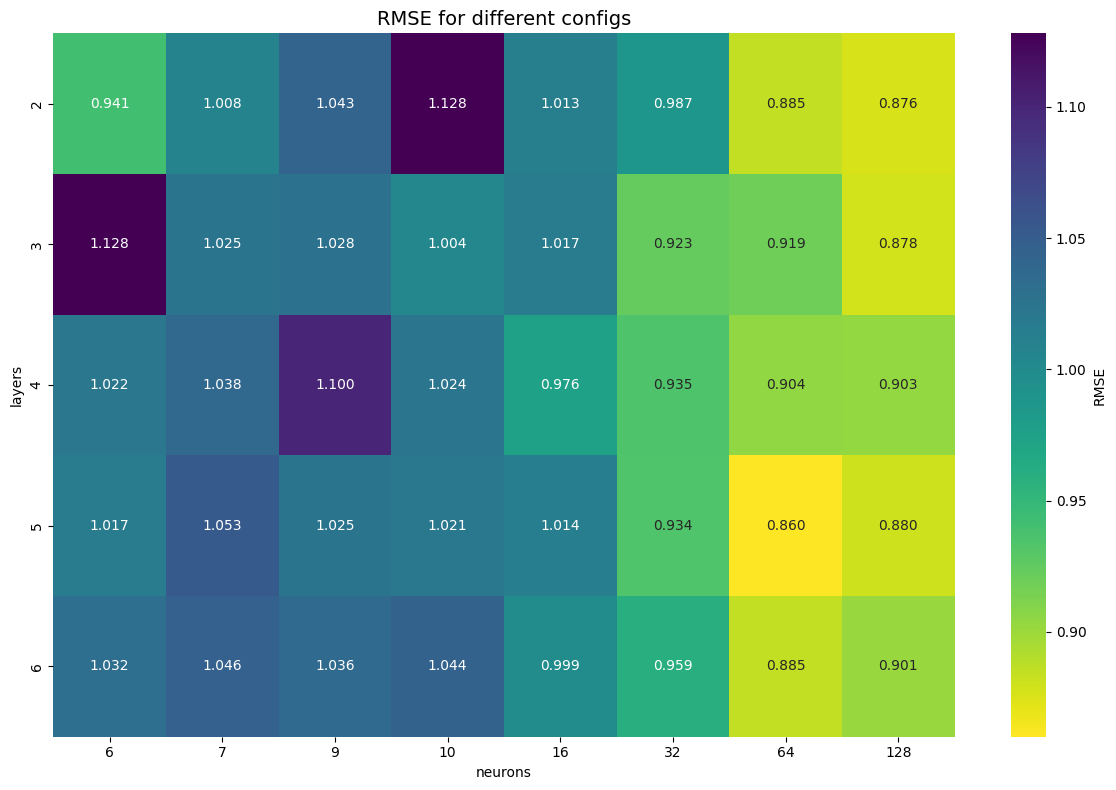

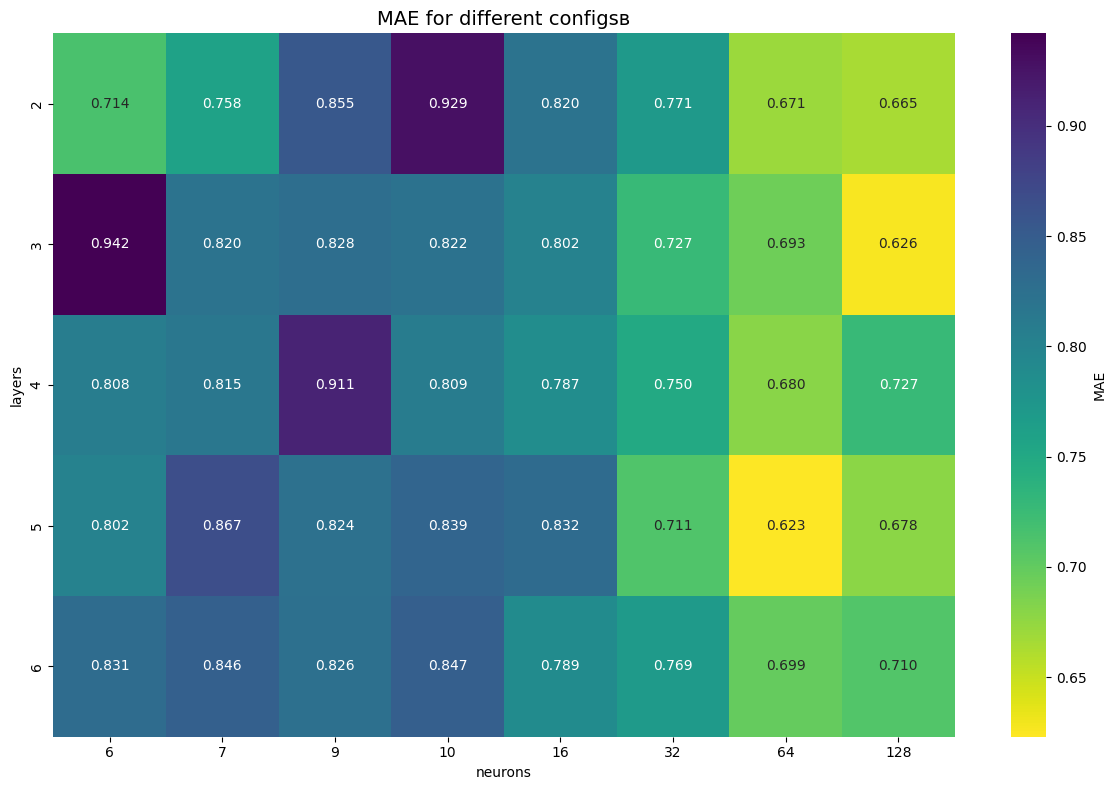

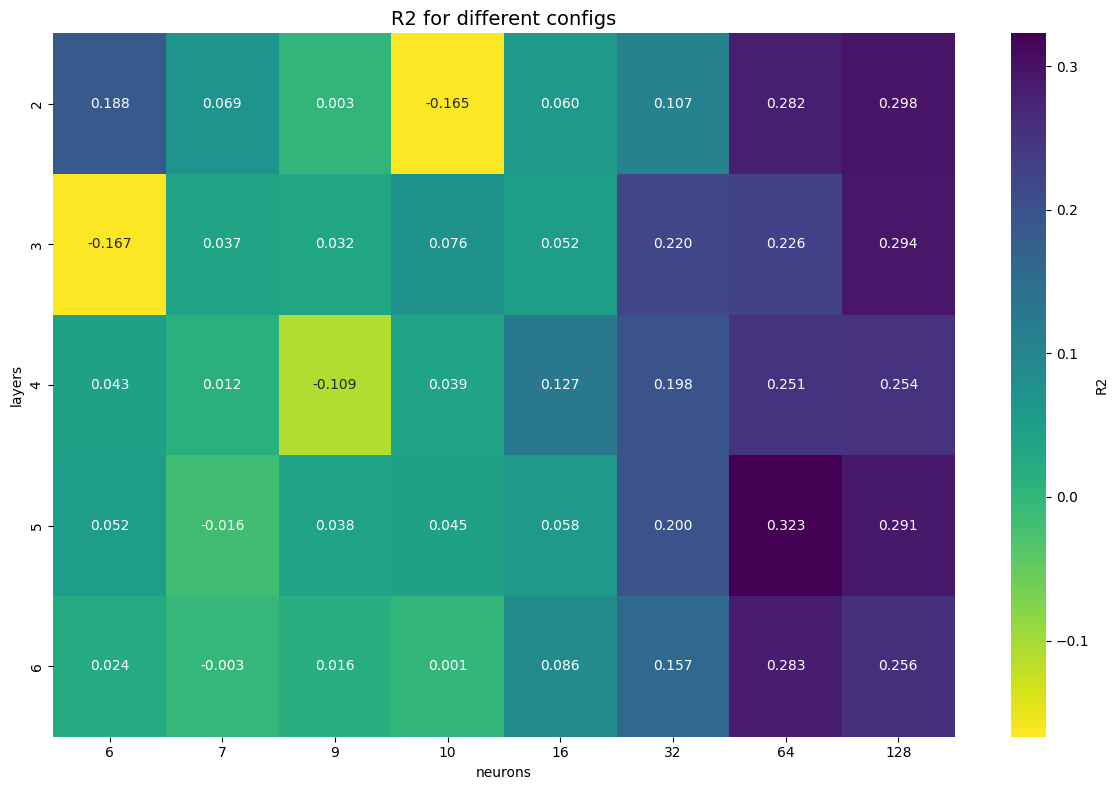

In [20]:
all_results = []
for i, l in enumerate(layers):
    for j, n in enumerate(neurons):
        rmse, mae, r2 = metrics_diff_lay_neur[i][j]
        all_results.append((rmse, l, n, mae, r2))

top_10 = sorted(all_results)[:10]

print(f"{'№':<3} {'Layers':<8} {'Neurons':<10} {'RMSE':<8} {'MAE':<8} {'R²':<8}")
print("-" * 50)

for i, (rmse, l, n, mae, r2) in enumerate(top_10, 1):
    print(f"{i:<3} {l:<8} {n:<10} {rmse:<8} {mae:<8} {r2:<8}")


# heatmap by RMSE matrix
rmse_matrix = np.array([[metrics_diff_lay_neur[i][j][0]
                         for j in range(len(neurons))]
                        for i in range(len(layers))])

plt.figure(figsize=(12, 8))
sns.heatmap(rmse_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=neurons,
            yticklabels=layers,
            cmap='viridis_r',
            cbar_kws={'label': 'RMSE'}
            )
plt.title('RMSE for different configs', fontsize=14)
plt.xlabel('neurons')
plt.ylabel('layers')
plt.tight_layout()
plt.show()

# heatmap by MAE matrix
mae_matrix = np.array([[metrics_diff_lay_neur[i][j][1]
                         for j in range(len(neurons))]
                        for i in range(len(layers))])

plt.figure(figsize=(12, 8))
sns.heatmap(mae_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=neurons,
            yticklabels=layers,
            cmap='viridis_r',
            cbar_kws={'label': 'MAE'}
            )
plt.title('MAE for different configsв', fontsize=14)
plt.xlabel('neurons')
plt.ylabel('layers')
plt.tight_layout()
plt.show()

# heatmap by R2 matrix
r2_matrix = np.array([[metrics_diff_lay_neur[i][j][2]
                         for j in range(len(neurons))]
                        for i in range(len(layers))])

plt.figure(figsize=(12, 8))
sns.heatmap(r2_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=neurons,
            yticklabels=layers,
            cmap='viridis_r',
            cbar_kws={'label': 'R2'}
            )
plt.title('R2 for different configs', fontsize=14)
plt.xlabel('neurons')
plt.ylabel('layers')
plt.tight_layout()
plt.show()

So basic option adam+relu is working good for this task, so next experiments will be done using this combination

Check for overfitting

In [21]:
model_new = build_model(X_train, optimizer='adam', activator='relu', layers=2, neurons=64)
early_stopping_monitor = EarlyStopping(patience=3)
model_new.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[early_stopping_monitor],
    verbose=0
)

y_predictions_test = model_new.predict(X_test)
y_predictions_train = model_new.predict(X_train)
test_metrics = get_metrics(y_test, y_predictions_test)
train_metrics = get_metrics(y_train, y_predictions_train)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [22]:
print('train')
print('RMSE\tMAE\t\tR2')
print('%.3f' % train_metrics[0], '\t%.3f' % train_metrics[1], '\t%.3f' % train_metrics[2])

print('test')
print('RMSE\tMAE\t\tR2')
print('%.3f' % test_metrics[0], '\t%.3f' % test_metrics[1], '\t%.3f' % test_metrics[2])

train
RMSE	MAE		R2
0.801 	0.554 	0.358
test
RMSE	MAE		R2
0.883 	0.654 	0.286
